# Data Loading and Dataset Audit

Import the libraries used for loading, checking, and preparing the dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
import glob

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

Extract the uploaded ZIP file into a working folder.

In [ ]:
zipPath = "./data.zip"
extractPath = "extractedData"

os.makedirs(extractPath, exist_ok=True)

with zipfile.ZipFile(zipPath, "r") as zipRef:
    zipRef.extractall(extractPath)

print("Extracted to:", extractPath)

Extracted to: extractedData


Find all CSV files inside the extracted folder.

In [ ]:
allCsvFiles = glob.glob(os.path.join(extractPath, "**", "*.csv"), recursive=True)

print("CSV files found:", len(allCsvFiles))
allCsvFiles[:5]

CSV files found: 54


['extractedData/2025-04/2025-04-west-midlands-street.csv',
 'extractedData/2025-04/2025-04-city-of-london-street.csv',
 'extractedData/2024-12/2024-12-city-of-london-street.csv',
 'extractedData/2024-12/2024-12-west-midlands-street.csv',
 'extractedData/2024-04/2024-04-city-of-london-street.csv']

Load all CSV files and combine them into one dataset.

In [ ]:
dataFrames = []

for filePath in allCsvFiles:
    tempDf = pd.read_csv(filePath)
    dataFrames.append(tempDf)

df = pd.concat(dataFrames, ignore_index=True)

print("Combined dataset shape:", df.shape)
df.head()

Combined dataset shape: (772974, 12)


,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,d3c91a6261bb4d0989a3a4597bad93ad33fd155772d352...,2025-04,West Midlands Police,West Midlands Police,-1.848972,52.588428,On or near Woodside,E01009417,Birmingham 001A,Burglary,Court result unavailable,NaN
1,79aeeb501c3d2a3764f6df8954ea5744cc002aaf8e7015...,2025-04,West Midlands Police,West Midlands Police,-1.849177,52.593202,On or near Russell Bank Road,E01009417,Birmingham 001A,Other theft,Investigation complete; no suspect identified,NaN
2,13d54c9959551c8d140e92573921b5822e4acf776b9c08...,2025-04,West Midlands Police,West Midlands Police,-1.849790,52.590937,On or near Walsall Road,E01009417,Birmingham 001A,Shoplifting,Unable to prosecute suspect,NaN
3,ca5d14a2d5b319e4b9217c2d590c2830e0ecba379f19e4...,2025-04,West Midlands Police,West Midlands Police,-1.854357,52.593739,On or near Walsall Road,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified,NaN
4,41f1012099ebf4c56616e47f97da74c5b73d3f05f068ab...,2025-04,West Midlands Police,West Midlands Police,-1.847899,52.591564,On or near Royal Park Close,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified,NaN


Check that the required columns exist in the dataset.

In [ ]:
requiredColumns = [
    "Crime ID",
    "Month",
    "Reported by",
    "Falls within",
    "Longitude",
    "Latitude",
    "Location",
    "LSOA code",
    "LSOA name",
    "Crime type",
    "Last outcome category",
    "Context"
]

missingColumns = [col for col in requiredColumns if col not in df.columns]

print("Missing required columns:", missingColumns)

Missing required columns: []


Check which police forces are present and compare them with the expected forces.

In [ ]:
expectedForces = [
    "Greater Manchester Police",
    "City of London Police",
    "West Midlands Police"
]

presentForces = sorted(df["Falls within"].dropna().unique().tolist())
missingForces = [force for force in expectedForces if force not in presentForces]

print("Present forces:", presentForces)
print("Missing expected forces:", missingForces)

Present forces: ['City of London Police', 'West Midlands Police']
Missing expected forces: ['Greater Manchester Police']


Count records by police force to understand the balance of the dataset.

In [ ]:
forceCounts = df["Falls within"].value_counts()

forceCounts

,count
Falls within,
West Midlands Police,751566
City of London Police,21408


Show the percentage share of each police force in the dataset.

In [ ]:
forcePercent = (df["Falls within"].value_counts(normalize=True) * 100).round(2)

forcePercent

,proportion
Falls within,
West Midlands Police,97.23
City of London Police,2.77


Inspect data types to identify categorical, numerical, time, and spatial fields.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 772974 entries, 0 to 772973
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Crime ID               715856 non-null  object 
 1   Month                  772974 non-null  object 
 2   Reported by            772974 non-null  object 
 3   Falls within           772974 non-null  object 
 4   Longitude              771151 non-null  float64
 5   Latitude               771151 non-null  float64
 6   Location               772974 non-null  object 
 7   LSOA code              771151 non-null  object 
 8   LSOA name              771151 non-null  object 
 9   Crime type             772974 non-null  object 
 10  Last outcome category  715856 non-null  object 
 11  Context                0 non-null       float64
dtypes: float64(3), object(9)
memory usage: 70.8+ MB


Create a simple field type summary for the report and viva.

In [ ]:
categoricalFields = [
    "Crime ID",
    "Reported by",
    "Falls within",
    "Location",
    "LSOA code",
    "LSOA name",
    "Crime type",
    "Last outcome category"
]

numericalFields = [
    "Latitude",
    "Longitude"
]

timeFields = [
    "Month"
]

spatialFields = [
    "Latitude",
    "Longitude",
    "LSOA code",
    "LSOA name",
    "Location"
]

fieldSummary = pd.DataFrame({
    "Field Group": ["Categorical", "Numerical", "Time", "Spatial"],
    "Fields": [
        ", ".join(categoricalFields),
        ", ".join(numericalFields),
        ", ".join(timeFields),
        ", ".join(spatialFields)
    ]
})

fieldSummary

,Field Group,Fields
0,Categorical,"Crime ID, Reported by, Falls within, Location,..."
1,Numerical,"Latitude, Longitude"
2,Time,Month
3,Spatial,"Latitude, Longitude, LSOA code, LSOA name, Loc..."


Check missing values to understand data quality.

In [ ]:
missingPercent = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)

missingPercent

,0
Context,100.00
Crime ID,7.39
Last outcome category,7.39
Longitude,0.24
LSOA name,0.24
LSOA code,0.24
Latitude,0.24
Month,0.00
Falls within,0.00
Reported by,0.00


Create a missing value summary table for the main report.

In [ ]:
missingSummary = pd.DataFrame({
    "Column": df.columns,
    "Missing Percent": (df.isnull().mean() * 100).round(2).values
}).sort_values("Missing Percent", ascending=False)

missingSummary

,Column,Missing Percent
11,Context,100.00
0,Crime ID,7.39
10,Last outcome category,7.39
4,Longitude,0.24
8,LSOA name,0.24
7,LSOA code,0.24
5,Latitude,0.24
1,Month,0.00
3,Falls within,0.00
2,Reported by,0.00


Convert the month column to datetime and create year and month number.

In [ ]:
df["Month"] = pd.to_datetime(df["Month"], errors="coerce")
df = df.dropna(subset=["Month"])

df["year"] = df["Month"].dt.year
df["monthNum"] = df["Month"].dt.month

df[["Month", "year", "monthNum"]].head()

,Month,year,monthNum
0,2025-04-01,2025,4
1,2025-04-01,2025,4
2,2025-04-01,2025,4
3,2025-04-01,2025,4
4,2025-04-01,2025,4


Check the time range covered by the dataset.

In [ ]:
print("Start month:", df["Month"].min())
print("End month:", df["Month"].max())
print("Total unique months:", df["Month"].nunique())

Start month: 2023-10-01 00:00:00
End month: 2025-12-01 00:00:00
Total unique months: 27


Check the number of unique LSOA areas covered in the dataset.

In [ ]:
print("Unique LSOA codes:", df["LSOA code"].nunique())

Unique LSOA codes: 1963


Summarise the dataset in a short and useful table.

In [ ]:
datasetSummary = pd.DataFrame({
    "Metric": [
        "Total records",
        "Total columns",
        "Police forces present",
        "Missing expected forces",
        "Unique months",
        "Unique LSOA codes"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        len(presentForces),
        len(missingForces),
        df["Month"].nunique(),
        df["LSOA code"].nunique()
    ]
})

datasetSummary

,Metric,Value
0,Total records,772974
1,Total columns,14
2,Police forces present,2
3,Missing expected forces,1
4,Unique months,27
5,Unique LSOA codes,1963


Audit summary

In [ ]:
print("Dataset audit summary")
print("- Total records:", df.shape[0])
print("- Total columns:", df.shape[1])
print("- Forces present:", presentForces)
print("- Missing expected forces:", missingForces)
print("- Date range:", df["Month"].min().date(), "to", df["Month"].max().date())
print("- Unique LSOA codes:", df["LSOA code"].nunique())

Dataset audit summary
- Total records: 772974
- Total columns: 14
- Forces present: ['City of London Police', 'West Midlands Police']
- Missing expected forces: ['Greater Manchester Police']
- Date range: 2023-10-01 to 2025-12-01
- Unique LSOA codes: 1963


# EDA

Plot the monthly crime trend to see how crime changes over time.

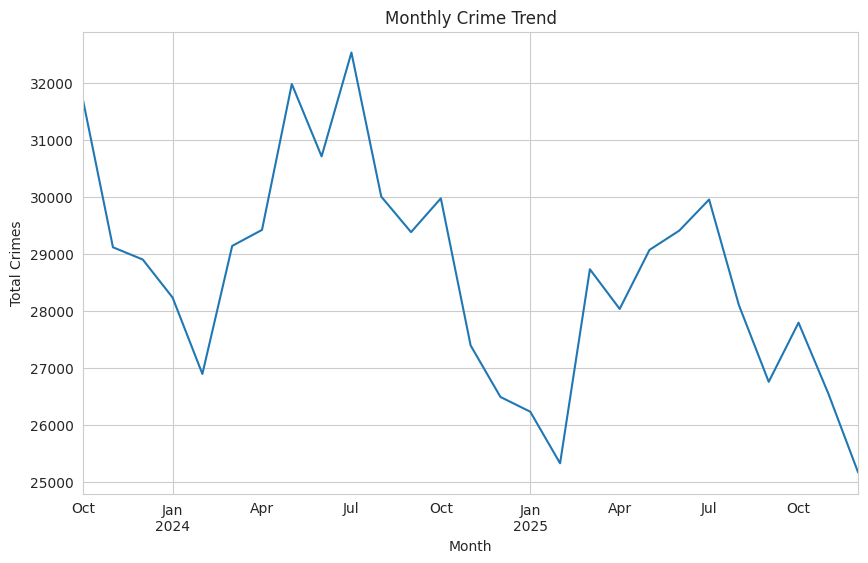

In [ ]:
monthlyTrend = df.groupby("Month").size()

monthlyTrend.plot()
plt.title("Monthly Crime Trend")
plt.xlabel("Month")
plt.ylabel("Total Crimes")
plt.show()

Plot the monthly crime trend to see how crime changes over time.

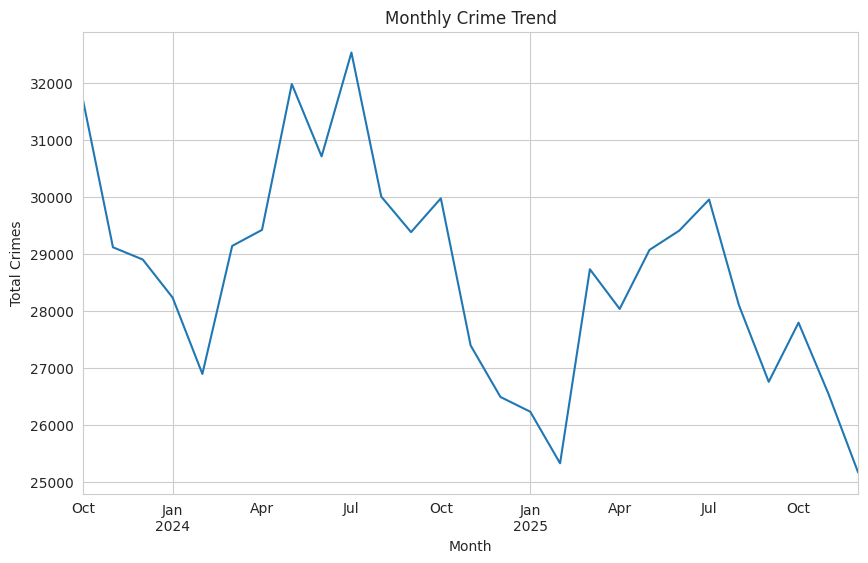

In [ ]:
monthlyTrend = df.groupby("Month").size()

monthlyTrend.plot()
plt.title("Monthly Crime Trend")
plt.xlabel("Month")
plt.ylabel("Total Crimes")
plt.show()

This graph shows that crime changes over time and does not stay at the same level.

Plot crime by month number to check seasonal patterns.

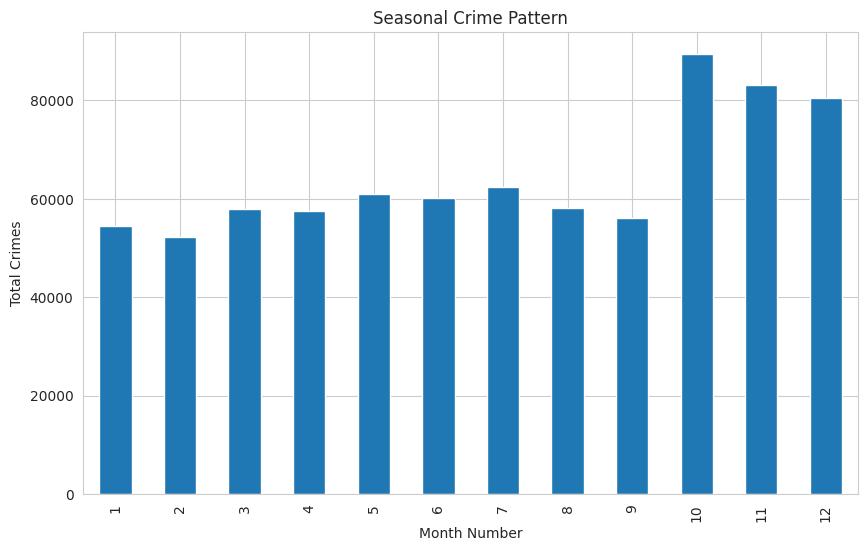

In [ ]:
seasonalTrend = df.groupby("monthNum").size()

seasonalTrend.plot(kind="bar")
plt.title("Seasonal Crime Pattern")
plt.xlabel("Month Number")
plt.ylabel("Total Crimes")
plt.show()

This graph shows whether some months have more crime than others.

Plot the top 10 crime types to understand crime composition.

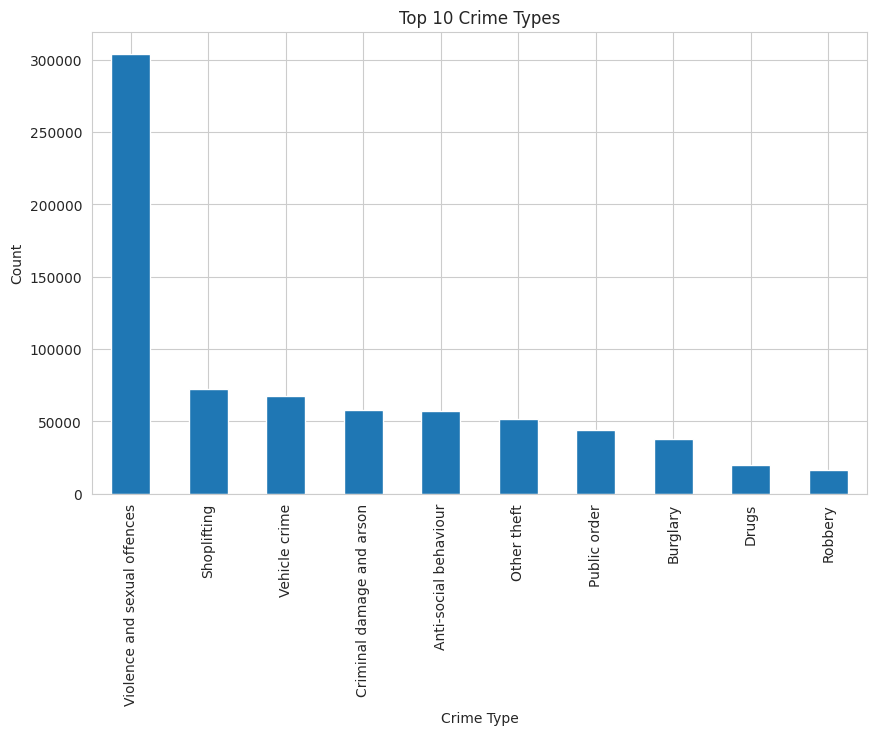

In [ ]:
topCrimeTypes = df["Crime type"].value_counts().head(10)

topCrimeTypes.plot(kind="bar")
plt.title("Top 10 Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.show()

This graph shows which crime categories are most common in the dataset.

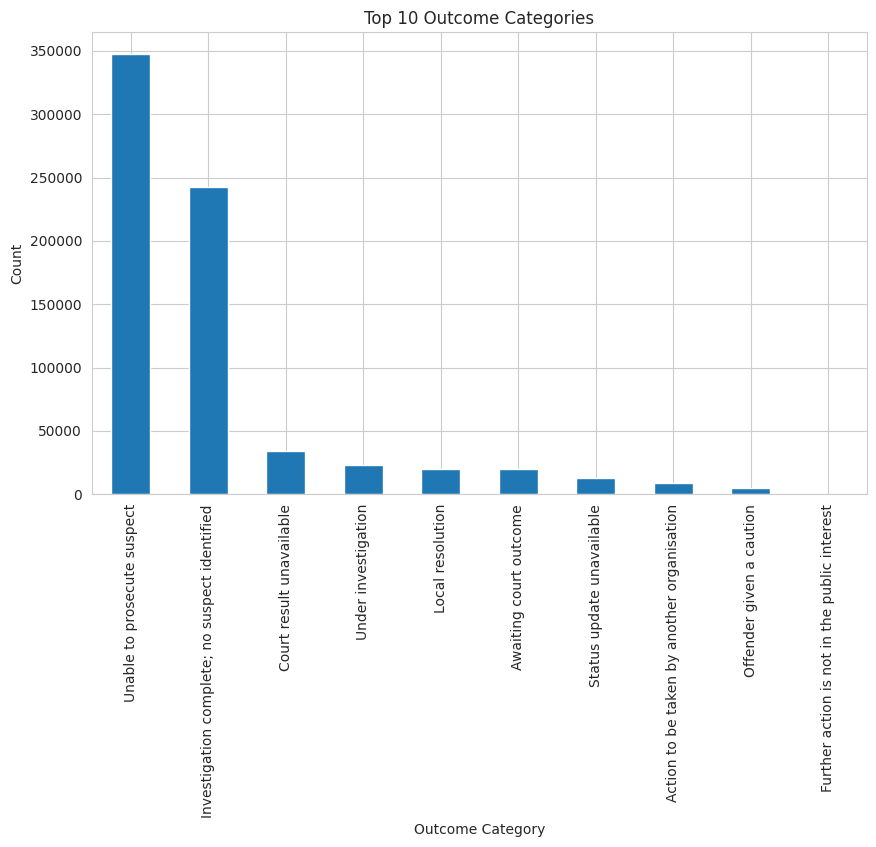

In [ ]:
topOutcomes = df["Last outcome category"].value_counts().head(10)

topOutcomes.plot(kind="bar")
plt.title("Top 10 Outcome Categories")
plt.xlabel("Outcome Category")
plt.ylabel("Count")
plt.show()

This graph shows what usually happens after a crime is reported.

Plot crime counts by police force to compare data balance.

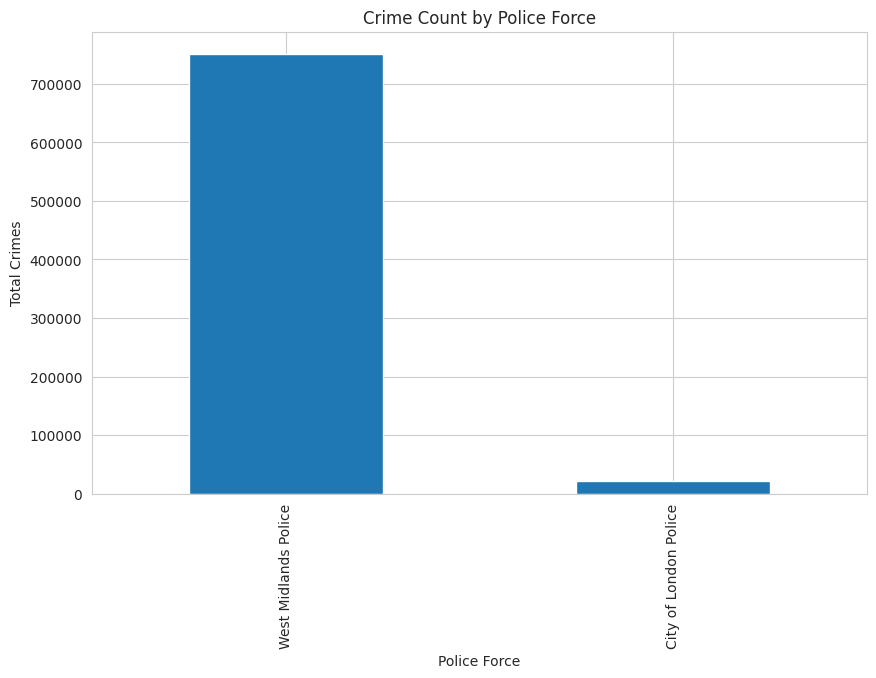

In [ ]:
forceCounts = df["Falls within"].value_counts()

forceCounts.plot(kind="bar")
plt.title("Crime Count by Police Force")
plt.xlabel("Police Force")
plt.ylabel("Total Crimes")
plt.show()

This graph shows whether one police force has much more data than another.

Plot the spatial distribution of crimes using latitude and longitude.

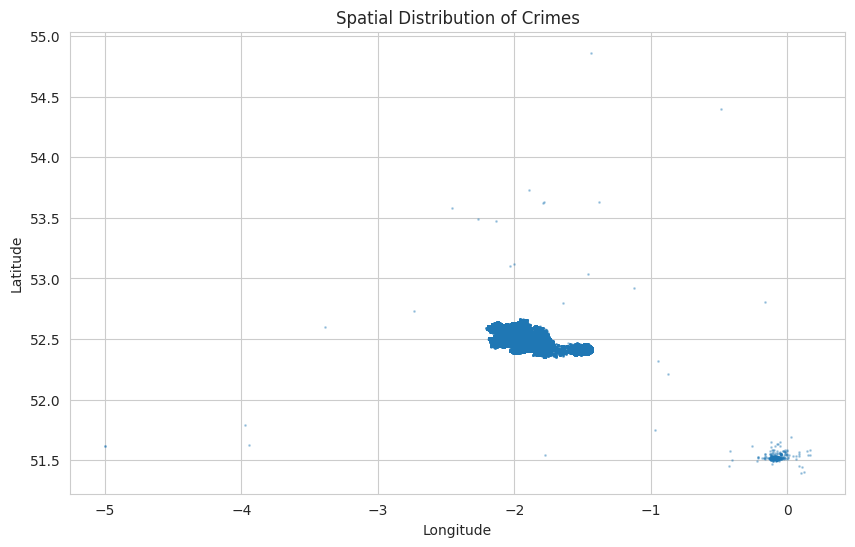

In [ ]:
dfGeo = df.dropna(subset=["Latitude", "Longitude"])

plt.scatter(dfGeo["Longitude"], dfGeo["Latitude"], s=1, alpha=0.3)
plt.title("Spatial Distribution of Crimes")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

This graph shows where crime is concentrated across the map.

Plot heatmap to show the relationship between key features and crime count to understand which variables are most useful for prediction

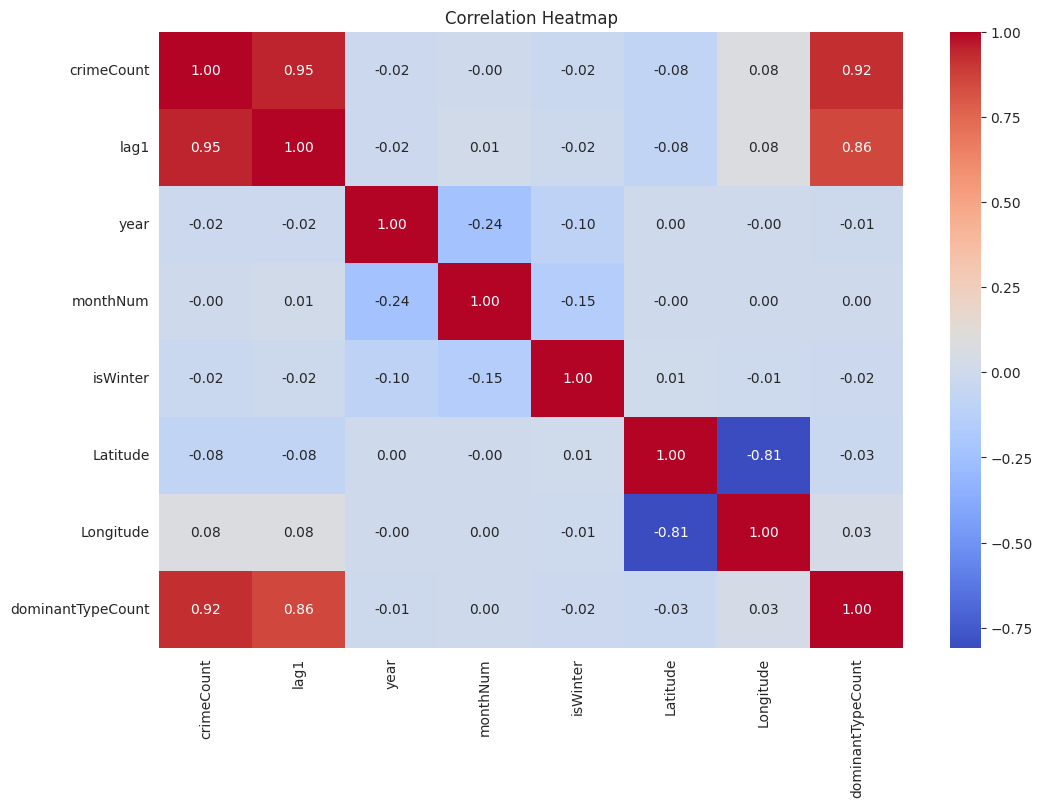

In [ ]:
plt.figure(figsize=(12, 8))

heatmapCols = [
    "crimeCount",
    "lag1",
    "year",
    "monthNum",
    "isWinter",
    "Latitude",
    "Longitude",
    "dominantTypeCount"
]

corrMatrix = forecastDf[heatmapCols].corr()

sns.heatmap(
    corrMatrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Show the top 10 LSOA areas with the highest crime counts.

In [ ]:
topLsoaCounts = df["LSOA code"].value_counts().head(10)

topLsoaCounts

,count
LSOA code,
E01032739,13454
E01033620,13402
E01010368,5250
E01034743,4884
E01033615,4815
E01034313,4333
E01033617,4285
E01033561,4255
E01034744,4097


This table shows the areas with the highest number of recorded crimes.

Create the LSOA-month dataset for modelling.

In [ ]:
aggLsoa = (
    df.groupby(["LSOA code", "year", "monthNum"])
      .size()
      .reset_index(name="crimeCount")
)

aggLsoa.head()

,LSOA code,year,monthNum,crimeCount
0,E01000001,2023,10,6
1,E01000001,2023,11,19
2,E01000001,2023,12,6
3,E01000001,2024,1,14
4,E01000001,2024,2,8


This step changes street-level data into area-level monthly crime counts.

Add average latitude and longitude for each LSOA.

In [ ]:
lsoaSpatial = (
    df.groupby("LSOA code")
      .agg({
          "Latitude": "mean",
          "Longitude": "mean"
      })
      .reset_index()
)

aggLsoa = aggLsoa.merge(lsoaSpatial, on="LSOA code", how="left")

aggLsoa.head()

,LSOA code,year,monthNum,crimeCount,Latitude,Longitude
0,E01000001,2023,10,6,51.51746,-0.097484
1,E01000001,2023,11,19,51.51746,-0.097484
2,E01000001,2023,12,6,51.51746,-0.097484
3,E01000001,2024,1,14,51.51746,-0.097484
4,E01000001,2024,2,8,51.51746,-0.097484


This step adds spatial coordinates so each LSOA can be mapped and clustered.

Save the aggregated dataset for clustering and forecasting.

In [ ]:
os.makedirs("outputs", exist_ok=True)
aggLsoa.to_csv("outputs/aggregatedLsoaMonth.csv", index=False)

print("Saved:", "outputs/aggregatedLsoaMonth.csv", "rows:", len(aggLsoa))

Saved: outputs/aggregatedLsoaMonth.csv rows: 47098


Check the distribution of crime count after aggregation.

In [ ]:
aggLsoa["crimeCount"].describe()

,crimeCount
count,47098.000000
mean,16.373328
std,23.658821
min,1.000000
25%,6.000000
50%,12.000000
75%,19.000000
max,620.000000


This table shows whether crime count is balanced or highly skewed.

Create a log version of crime count to reduce skew for clustering.

In [ ]:
aggLsoa["logCrime"] = np.log1p(aggLsoa["crimeCount"])

aggLsoa["logCrime"].describe()

,logCrime
count,47098.000000
mean,2.510551
std,0.797841
min,0.693147
25%,1.945910
50%,2.564949
75%,2.995732
max,6.431331


This step reduces the effect of very large crime counts before clustering.

# Hotspot Detection Using Clustering (RQ1)

Prepare features for clustering using crime intensity, location, and time.

In [ ]:
from sklearn.preprocessing import StandardScaler

clusterFeatures = aggLsoa[["logCrime", "Latitude", "Longitude", "monthNum"]]

scaler = StandardScaler()
clusterScaled = scaler.fit_transform(clusterFeatures)

Apply KMeans clustering to group areas based on crime patterns.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeansModel = KMeans(n_clusters=4, random_state=42)

kmeansLabels = kmeansModel.fit_predict(clusterScaled)

aggLsoa["kmeansCluster"] = kmeansLabels

kmeansScore = silhouette_score(clusterScaled, kmeansLabels)

print("KMeans Silhouette Score:", kmeansScore)

KMeans Silhouette Score: 0.26564483765196323


Visualise spatial clusters from KMeans.

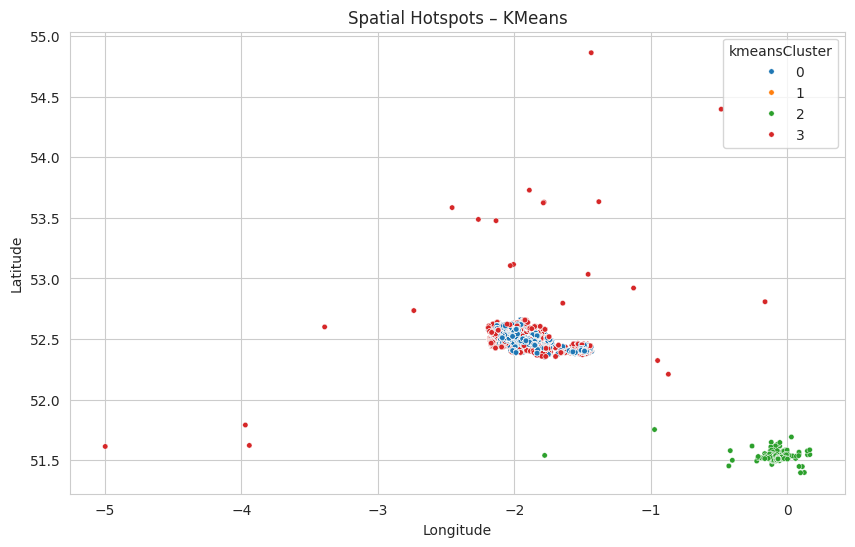

In [ ]:
sns.scatterplot(
    x="Longitude",
    y="Latitude",
    hue="kmeansCluster",
    data=aggLsoa,
    palette="tab10",
    s=15
)

plt.title("Spatial Hotspots – KMeans")
plt.show()

KMeans groups areas broadly but may not clearly isolate extreme hotspots.

Apply DBSCAN clustering to detect dense crime hotspots.

In [ ]:
from sklearn.cluster import DBSCAN

dbscanModel = DBSCAN(eps=0.8, min_samples=10)

dbscanLabels = dbscanModel.fit_predict(clusterScaled)

aggLsoa["dbscanCluster"] = dbscanLabels

if len(set(dbscanLabels)) > 1:
    dbscanScore = silhouette_score(clusterScaled, dbscanLabels)
    print("DBSCAN Silhouette Score:", dbscanScore)

DBSCAN Silhouette Score: 0.7418125631665681


Check number of points in each DBSCAN cluster.

In [ ]:
pd.Series(aggLsoa["dbscanCluster"]).value_counts()

,count
dbscanCluster,
1,46396
0,646
-1,29
2,27


Check average crime level in each cluster.

In [ ]:
aggLsoa.groupby("dbscanCluster")["crimeCount"].mean()

,crimeCount
dbscanCluster,
-1,1.034483
0,9.439628
1,16.199004
2,498.296296


Visualise crime intensity across DBSCAN clusters.

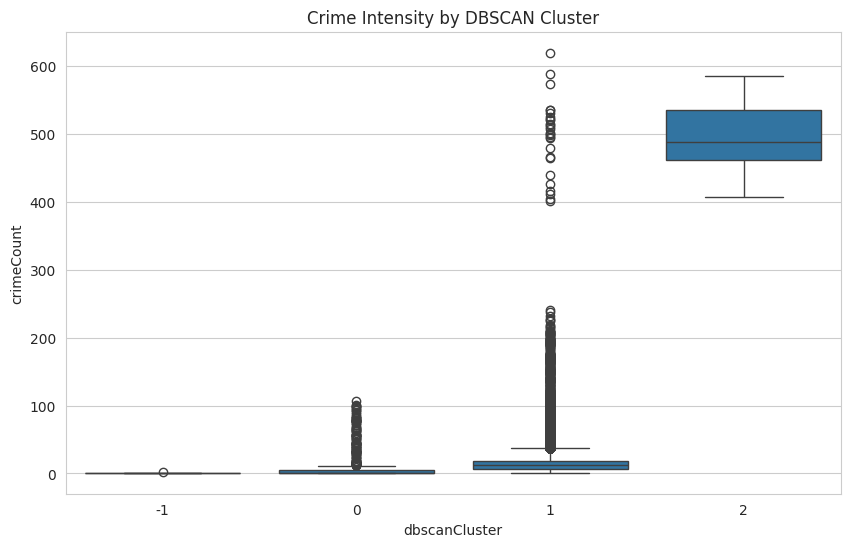

In [ ]:
sns.boxplot(x="dbscanCluster", y="crimeCount", data=aggLsoa)
plt.title("Crime Intensity by DBSCAN Cluster")
plt.show()

DBSCAN can identify extreme high-crime clusters that KMeans cannot clearly separate.

Inspect extreme hotspot cluster (highest crime cluster).

In [ ]:
highCluster = aggLsoa.groupby("dbscanCluster")["crimeCount"].mean().idxmax()

aggLsoa[aggLsoa["dbscanCluster"] == highCluster].head()

,LSOA code,year,monthNum,crimeCount,Latitude,Longitude,logCrime,kmeansCluster,dbscanCluster
43857,E01032739,2023,10,546,51.513967,-0.08724,6.304449,2,2
43858,E01032739,2023,11,533,51.513967,-0.08724,6.280396,2,2
43859,E01032739,2023,12,521,51.513967,-0.08724,6.257668,2,2
43860,E01032739,2024,1,414,51.513967,-0.08724,6.028279,2,2
43861,E01032739,2024,2,521,51.513967,-0.08724,6.257668,2,2


Check which police force these hotspots belong to.

In [ ]:
df.merge(
    aggLsoa[["LSOA code", "dbscanCluster"]],
    on="LSOA code"
).query("dbscanCluster == @highCluster")["Falls within"].value_counts()

,count
Falls within,
City of London Police,363258


# Crime Forecasting Using Regression Models (RQ2)

Create a feature that shows the most common crime type in each area and month.

In [ ]:
crimeTypeCounts = (
    df.groupby(["LSOA code", "year", "monthNum", "Crime type"])
      .size()
      .reset_index(name="typeCount")
)

dominantType = (
    crimeTypeCounts.sort_values("typeCount", ascending=False)
      .drop_duplicates(["LSOA code", "year", "monthNum"])
)

dominantType = dominantType.rename(columns={"typeCount": "dominantTypeCount"})

dominantType = dominantType[["LSOA code", "year", "monthNum", "dominantTypeCount"]]

Merge the crime composition feature into the main dataset.

In [ ]:
forecastDf = aggLsoa.merge(
    dominantType,
    on=["LSOA code", "year", "monthNum"],
    how="left"
)

Create seasonal and lag features to capture time patterns.

In [ ]:
forecastDf["isWinter"] = forecastDf["monthNum"].isin([12, 1, 2]).astype(int)

forecastDf = forecastDf.sort_values(["LSOA code", "year", "monthNum"])

forecastDf["lag1"] = forecastDf.groupby("LSOA code")["crimeCount"].shift(1)

forecastDf = forecastDf.dropna()

Encode location so it can be used in the model.

In [ ]:
forecastDf["lsoaEncoded"] = forecastDf["LSOA code"].astype("category").cat.codes

Define the features and target variable for prediction.

In [ ]:
featureCols = [
    "lag1",
    "year",
    "monthNum",
    "isWinter",
    "Latitude",
    "Longitude",
    "dominantTypeCount",
    "lsoaEncoded"
]

X = forecastDf[featureCols]
y = forecastDf["crimeCount"]

print("Feature shape:", X.shape)

Feature shape: (45135, 8)


Split the data based on time to simulate real-world prediction.

In [ ]:
trainData = forecastDf[forecastDf["year"] < 2025]
testData = forecastDf[forecastDf["year"] >= 2025]

XTrain = trainData[featureCols]
yTrain = trainData["crimeCount"]

XTest = testData[featureCols]
yTest = testData["crimeCount"]

This split is used because we want to predict future crime using past data.

Train a Linear Regression model as a simple baseline.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

lrModel = LinearRegression()

lrModel.fit(XTrain, yTrain)

predLr = lrModel.predict(XTest)

rmseLr = np.sqrt(mean_squared_error(yTest, predLr))
maeLr = mean_absolute_error(yTest, predLr)

print("Linear Regression RMSE:", rmseLr)
print("Linear Regression MAE:", maeLr)

Linear Regression RMSE: 5.354559516488904
Linear Regression MAE: 3.5184898614703393


Linear Regression assumes a simple linear relationship between features and crime.

Train a Random Forest model to capture complex patterns.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rfModel = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rfModel.fit(XTrain, yTrain)

predRf = rfModel.predict(XTest)

rmseRf = np.sqrt(mean_squared_error(yTest, predRf))
maeRf = mean_absolute_error(yTest, predRf)

print("Random Forest RMSE:", rmseRf)
print("Random Forest MAE:", maeRf)

Random Forest RMSE: 4.843926980951955
Random Forest MAE: 3.1089619925136764


Random Forest can capture non-linear relationships between time, location, and crime.

Compare both models to see which performs better.

In [ ]:
modelComparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [rmseLr, rmseRf],
    "MAE": [maeLr, maeRf]
})

modelComparison

,Model,RMSE,MAE
0,Linear Regression,5.354560,3.518490
1,Random Forest,4.843927,3.108962


# Overfitting Detection and Model Improvement

Check model performance on training and testing data to detect overfitting.

In [ ]:
trainPred = rfModel.predict(XTrain)

trainRmse = np.sqrt(mean_squared_error(yTrain, trainPred))
testRmse = np.sqrt(mean_squared_error(yTest, predRf))

print("Train RMSE:", trainRmse)
print("Test RMSE:", testRmse)

Train RMSE: 1.836959174709254
Test RMSE: 4.843926980951955


Training error is much lower than testing error, so the model is overfitting.

This shows that the model learns the training data too well but does not generalise to new data.

Apply regularisation by limiting tree depth and leaf size.

In [ ]:
rfRegModel = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rfRegModel.fit(XTrain, yTrain)

predRfReg = rfRegModel.predict(XTest)

trainPredReg = rfRegModel.predict(XTrain)

trainRmseReg = np.sqrt(mean_squared_error(yTrain, trainPredReg))
testRmseReg = np.sqrt(mean_squared_error(yTest, predRfReg))

print("Regularised Train RMSE:", trainRmseReg)
print("Regularised Test RMSE:", testRmseReg)

Regularised Train RMSE: 3.984854253799031
Regularised Test RMSE: 4.859431553024327


Regularisation reduces overfitting by limiting how complex the trees can grow.

Compare before and after regularisation.

In [ ]:
overfitComparison = pd.DataFrame({
    "Model": ["Original Random Forest", "Regularised Random Forest"],
    "Train RMSE": [trainRmse, trainRmseReg],
    "Test RMSE": [testRmse, testRmseReg]
})

overfitComparison

,Model,Train RMSE,Test RMSE
0,Original Random Forest,1.836959,4.843927
1,Regularised Random Forest,3.984854,4.859432


The gap between training and testing error becomes smaller after regularisation.

Visualise training vs testing error.

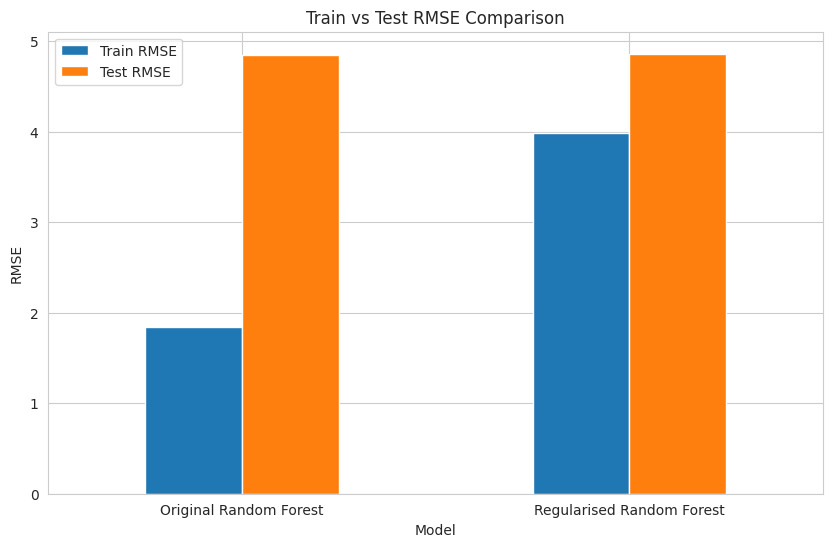

In [ ]:
overfitComparison.set_index("Model").plot(kind="bar")

plt.title("Train vs Test RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=0)
plt.show()

This graph clearly shows how regularisation improves generalisation.

# Feature Selection Using SelectKBest (RQ3 – Part 1)

Select the most important features using statistical feature selection.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

selectorAll = SelectKBest(score_func=f_regression, k="all")

selectorAll.fit(XTrain, yTrain)

featureScores = pd.DataFrame({
    "Feature": XTrain.columns,
    "Score": selectorAll.scores_
}).sort_values("Score", ascending=False)

featureScores

,Feature,Score
0,lag1,217262.643858
6,dominantTypeCount,138944.652991
5,Longitude,164.017619
4,Latitude,153.515790
7,lsoaEncoded,111.096214
3,isWinter,12.859092
2,monthNum,0.282288
1,year,0.024363


Higher score means the feature has stronger relationship with crime count.

Select the top 5 most important features.

In [ ]:
selectorTop5 = SelectKBest(score_func=f_regression, k=5)

XTrainTop5 = selectorTop5.fit_transform(XTrain, yTrain)
XTestTop5 = selectorTop5.transform(XTest)

top5Features = XTrain.columns[selectorTop5.get_support()]

print("Top 5 Features:", list(top5Features))

Top 5 Features: ['lag1', 'Latitude', 'Longitude', 'dominantTypeCount', 'lsoaEncoded']


Train a regularised Random Forest using only the top features.

In [ ]:
rfTop5Model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rfTop5Model.fit(XTrain[top5Features], yTrain)

predTop5 = rfTop5Model.predict(XTest[top5Features])

rmseTop5 = np.sqrt(mean_squared_error(yTest, predTop5))

print("RMSE using Top 5 Features:", rmseTop5)

RMSE using Top 5 Features: 4.824142179483622


Compare performance before and after feature selection.

In [ ]:
featureComparison = pd.DataFrame({
    "Model": ["All Features", "Top 5 Features"],
    "RMSE": [testRmseReg, rmseTop5]
})

featureComparison

,Model,RMSE
0,All Features,4.859432
1,Top 5 Features,4.824142


Visualise feature importance scores.

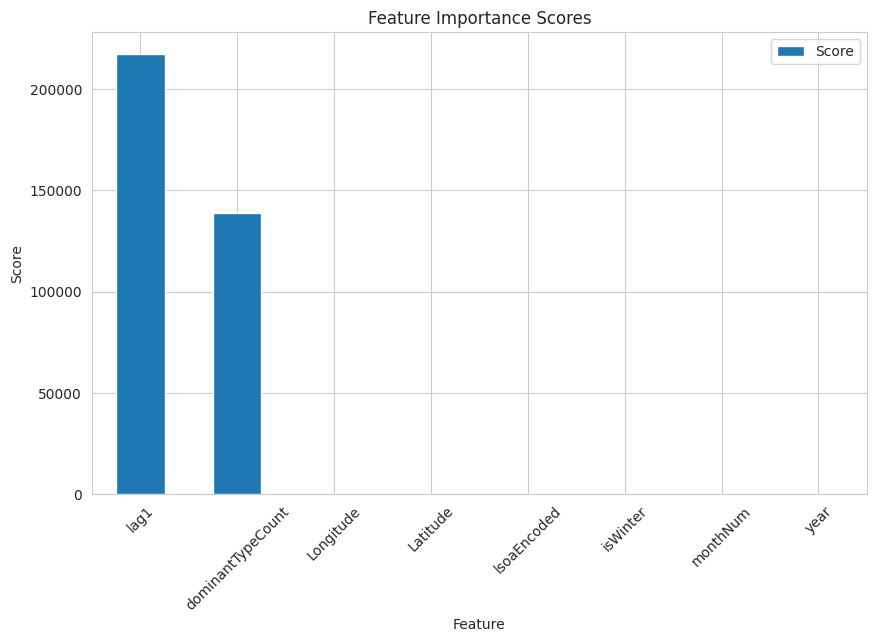

In [ ]:
featureScores.set_index("Feature").plot(kind="bar")

plt.title("Feature Importance Scores")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

The above graph shows which features have the strongest impact on prediction.

# SHAP Interpretability (RQ3 – Part 2)

Use SHAP to explain how each feature contributes to crime prediction.

In [ ]:
import shap

explainer = shap.TreeExplainer(rfTop5Model)

shapValues = explainer.shap_values(XTest[top5Features])

SHAP values show how each feature increases or decreases the prediction.

Visualise overall feature impact using SHAP summary plot.

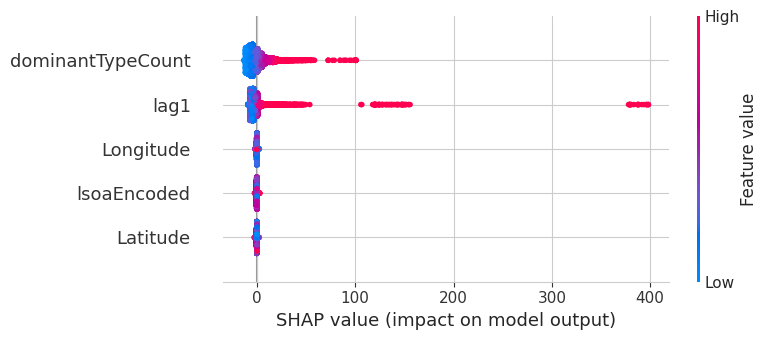

In [ ]:
shap.summary_plot(shapValues, XTest[top5Features])

This plot shows how each feature affects predictions across all data points.

Visualise average feature importance using SHAP bar plot.

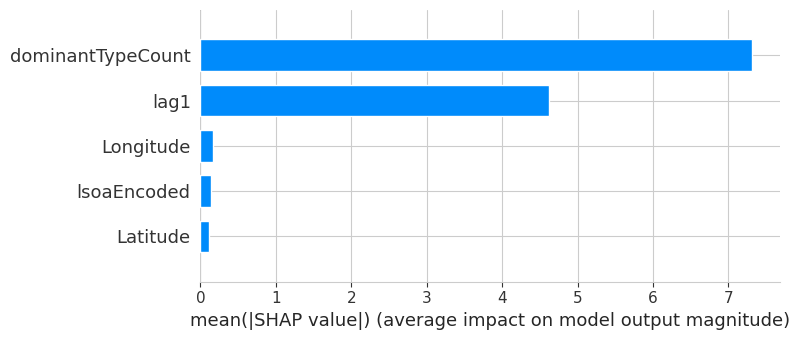

In [ ]:
shap.summary_plot(shapValues, XTest[top5Features], plot_type="bar")

This plot shows which features have the strongest overall impact.

# Model Validation Visualisations

Compare actual and predicted crime values to check prediction quality.

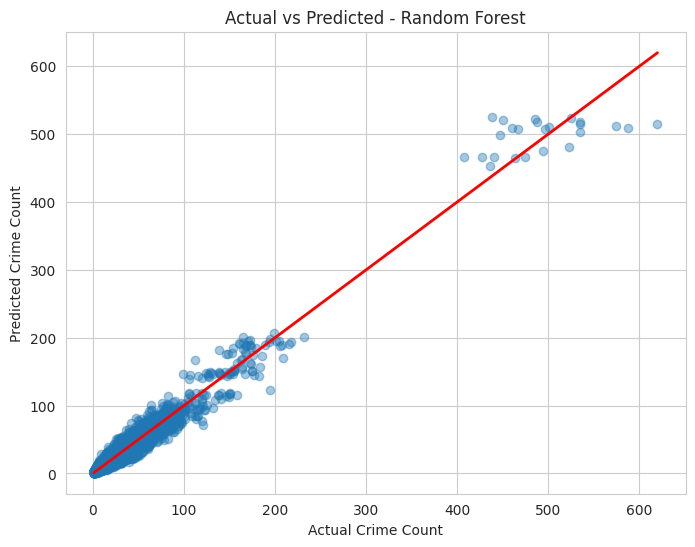

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(yTest, predRfReg, alpha=0.4)

# Add perfect prediction line
minVal = min(yTest.min(), predRfReg.min())
maxVal = max(yTest.max(), predRfReg.max())

plt.plot([minVal, maxVal], [minVal, maxVal], color='red', linewidth=2)

plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.title("Actual vs Predicted - Random Forest")

plt.show()

This graph shows how close predictions are to real values.

Calculate residuals to analyse prediction errors.

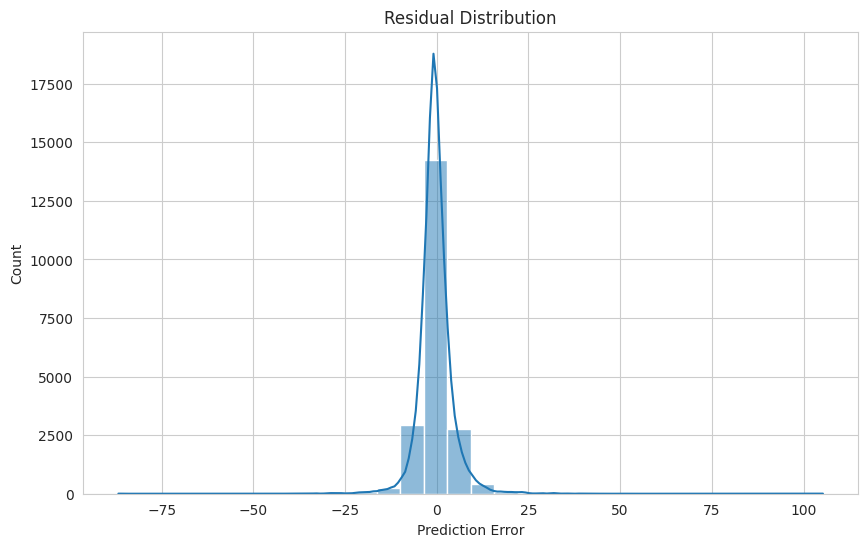

In [ ]:
residuals = yTest - predRfReg

sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.show()

Most errors should be close to zero if the model is good.

Compare training and testing error visually.

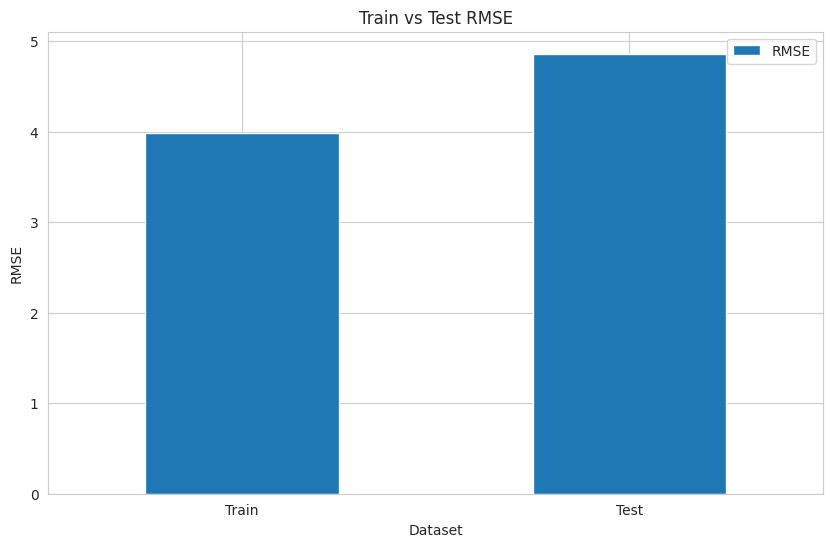

In [ ]:
rmseComparison = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "RMSE": [trainRmseReg, testRmseReg]
})

rmseComparison.set_index("Dataset").plot(kind="bar")

plt.title("Train vs Test RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=0)
plt.show()

This graph shows whether the model is overfitting or generalising well.

Plot learning curve to see how performance changes with more data.

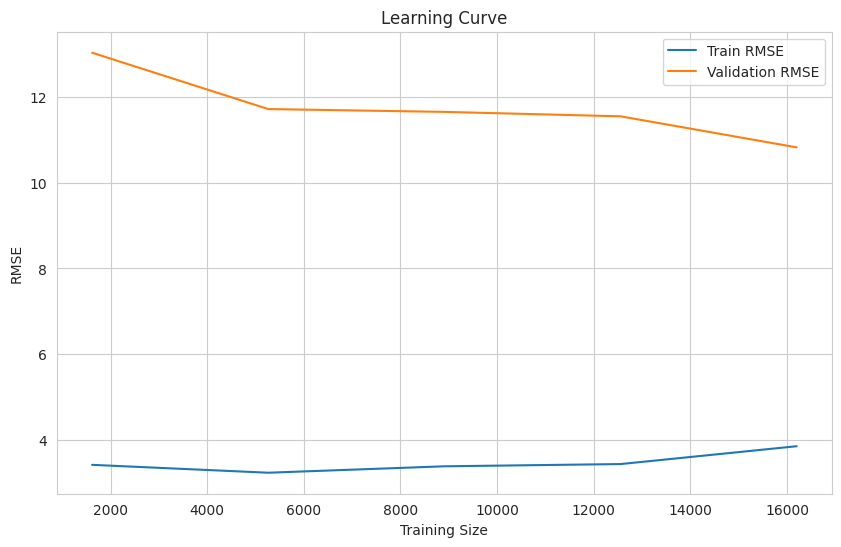

In [ ]:
from sklearn.model_selection import learning_curve

trainSizes, trainScores, testScores = learning_curve(
    rfRegModel,
    XTrain,
    yTrain,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

trainScoresMean = -trainScores.mean(axis=1)
testScoresMean = -testScores.mean(axis=1)

plt.plot(trainSizes, trainScoresMean, label="Train RMSE")
plt.plot(trainSizes, testScoresMean, label="Validation RMSE")

plt.xlabel("Training Size")
plt.ylabel("RMSE")
plt.title("Learning Curve")
plt.legend()
plt.show()

This graph shows whether more data could improve the model.

# Hyperparameter Tuning

Define parameter grid for tuning.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

paramGrid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 12, 16, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2"]
}

Use Randomized Search to find best parameters efficiently.

In [ ]:
rfBase = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rfSearch = RandomizedSearchCV(
    estimator=rfBase,
    param_distributions=paramGrid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1,
    random_state=42
)

rfSearch.fit(XTrain, yTrain)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=20,
                   param_distributions={'max_depth': [8, 12, 16, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 3, 5],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

Get the best parameters.

In [ ]:
bestParams = rfSearch.best_params_
print("Best Parameters:", bestParams)

Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 16}


Train final tuned model using best parameters.

In [ ]:
rfTunedModel = RandomForestRegressor(
    **bestParams,
    random_state=42,
    n_jobs=-1
)

rfTunedModel.fit(XTrain, yTrain)

predRfTuned = rfTunedModel.predict(XTest)

rmseTuned = np.sqrt(mean_squared_error(yTest, predRfTuned))

print("Tuned Model RMSE:", rmseTuned)

Tuned Model RMSE: 4.626201445633814


Compare tuned model with previous models.

In [ ]:
finalComparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Regularised RF", "Tuned RF"],
    "RMSE": [rmseLr, rmseRf, testRmseReg, rmseTuned]
})

finalComparison

,Model,RMSE
0,Linear Regression,5.354560
1,Random Forest,4.843927
2,Regularised RF,4.859432
3,Tuned RF,4.626201


# Save the tuned model and build reusable lookup tables for inference.

Save the tuned model and build reusable lookup tables for inference.

In [ ]:
import joblib
from pathlib import Path

# create folder
modelDir = Path("savedModels")
modelDir.mkdir(exist_ok=True)

# save tuned model
joblib.dump(rfTunedModel, modelDir / "crimeForecastModel.joblib")

print("Model saved to:", modelDir / "crimeForecastModel.joblib")

Model saved to: savedModels/crimeForecastModel.joblib


Rebuild dominant crime type table with both type and count.

In [ ]:
crimeTypeCountsFull = (
    df.groupby(["LSOA code", "year", "monthNum", "Crime type"])
      .size()
      .reset_index(name="typeCount")
)

dominantTypeFull = (
    crimeTypeCountsFull.sort_values("typeCount", ascending=False)
      .drop_duplicates(["LSOA code", "year", "monthNum"])
      .rename(columns={
          "Crime type": "dominantCrimeType",
          "typeCount": "dominantTypeCount"
      })
)

dominantTypeFull = dominantTypeFull[
    ["LSOA code", "year", "monthNum", "dominantCrimeType", "dominantTypeCount"]
]

Create the full inference dataset again so the latest row per area can be used for next-month prediction.

In [ ]:
forecastFullDf = aggLsoa.merge(
    dominantTypeFull,
    on=["LSOA code", "year", "monthNum"],
    how="left"
)

forecastFullDf["isWinter"] = forecastFullDf["monthNum"].isin([12, 1, 2]).astype(int)

forecastFullDf = forecastFullDf.sort_values(["LSOA code", "year", "monthNum"])

forecastFullDf["lag1"] = forecastFullDf.groupby("LSOA code")["crimeCount"].shift(1)

forecastFullDf = forecastFullDf.dropna().copy()

forecastFullDf["lsoaEncoded"] = forecastFullDf["LSOA code"].astype("category").cat.codes

Create the latest available row per LSOA for next-month prediction.

In [ ]:
latestLsoaRows = (
    forecastFullDf.sort_values(["LSOA code", "year", "monthNum"])
    .groupby("LSOA code")
    .tail(1)
    .copy()
)

latestLsoaRows.head()

,LSOA code,year,monthNum,crimeCount,Latitude,Longitude,logCrime,kmeansCluster,dbscanCluster,dominantCrimeType,dominantTypeCount,isWinter,lag1,lsoaEncoded
26,E01000001,2025,12,16,51.517460,-0.097484,2.833213,2,0,Bicycle theft,4,1,10.0,0
53,E01000002,2025,12,35,51.519004,-0.092016,3.583519,2,0,Shoplifting,13,1,29.0,1
80,E01000003,2025,12,13,51.521669,-0.095751,2.639057,2,0,Drugs,6,1,13.0,2
107,E01000005,2025,12,60,51.513168,-0.075539,4.110874,2,0,Shoplifting,24,1,50.0,3
143,E01000914,2025,12,3,51.518036,-0.111831,1.386294,2,0,Violence and sexual offences,2,1,3.0,4


Create a simple street-to-LSOA lookup using the most common match.

In [ ]:
streetLookup = (
    df.dropna(subset=["Location", "LSOA code"])
      .groupby(["Location", "LSOA code"])
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
      .drop_duplicates("Location")
      .drop(columns="count")
      .copy()
)

streetLookup.head()

,Location,LSOA code
26395,On or near Worcester Street,E01033620
11085,On or near High Street,E01033620
17590,On or near Parking Area,E01033615
15954,On or near New Street,E01033620
22776,On or near Supermarket,E01033620


Create a simple LSOA reference table for nearest-location lookup.

In [ ]:
lsoaLookup = latestLsoaRows[[
    "LSOA code",
    "Latitude",
    "Longitude",
    "crimeCount",
    "dominantCrimeType",
    "dominantTypeCount",
    "lsoaEncoded"
]].copy()

lsoaLookup.head()

,LSOA code,Latitude,Longitude,crimeCount,dominantCrimeType,dominantTypeCount,lsoaEncoded
26,E01000001,51.517460,-0.097484,16,Bicycle theft,4,0
53,E01000002,51.519004,-0.092016,35,Shoplifting,13,1
80,E01000003,51.521669,-0.095751,13,Drugs,6,2
107,E01000005,51.513168,-0.075539,60,Shoplifting,24,3
143,E01000914,51.518036,-0.111831,3,Violence and sexual offences,2,4


Save all reusable artifacts.

In [ ]:
artifacts = {
    "featureCols": featureCols,
    "latestLsoaRows": latestLsoaRows,
    "streetLookup": streetLookup,
    "lsoaLookup": lsoaLookup,
    "riskQuantiles": forecastFullDf["crimeCount"].quantile([0.25, 0.50, 0.75]).to_dict()
}

joblib.dump(artifacts, modelDir / "crimeForecastArtifacts.joblib")

print("Artifacts saved to:", modelDir / "crimeForecastArtifacts.joblib")

Artifacts saved to: savedModels/crimeForecastArtifacts.joblib


Create helper functions for resolving locations and predicting next-month crime.

In [ ]:
def getNextMonthYear(yearValue, monthValue):
    if monthValue == 12:
        return yearValue + 1, 1
    return yearValue, monthValue + 1


def getRiskBand(predictedCrimeCount, riskQuantiles):
    q25 = riskQuantiles[0.25]
    q50 = riskQuantiles[0.50]
    q75 = riskQuantiles[0.75]

    if predictedCrimeCount <= q25:
        return "Low"
    elif predictedCrimeCount <= q50:
        return "Moderate"
    elif predictedCrimeCount <= q75:
        return "High"
    return "Very High"


def resolveLsoaFromInput(
    latestLsoaRows,
    streetLookup,
    lsoaCode=None,
    streetName=None,
    latitude=None,
    longitude=None,
    query=None
):
    # 1. direct LSOA code match
    if lsoaCode is not None:
        matchDf = latestLsoaRows[latestLsoaRows["LSOA code"] == lsoaCode]
        if not matchDf.empty:
            return matchDf.iloc[0], f"Matched by LSOA code: {lsoaCode}"

    # 2. street name or general text query against street lookup
    searchText = streetName if streetName is not None else query
    if searchText is not None:
        searchText = str(searchText).strip().lower()

        streetMatches = streetLookup[
            streetLookup["Location"].str.lower().str.contains(searchText, na=False)
        ]

        if not streetMatches.empty:
            matchedLsoa = streetMatches.iloc[0]["LSOA code"]
            matchDf = latestLsoaRows[latestLsoaRows["LSOA code"] == matchedLsoa]
            if not matchDf.empty:
                return matchDf.iloc[0], f"Matched by street/query: {searchText}"

        # also try matching against LSOA code directly
        lsoaMatches = latestLsoaRows[
            latestLsoaRows["LSOA code"].str.lower().str.contains(searchText, na=False)
        ]
        if not lsoaMatches.empty:
            return lsoaMatches.iloc[0], f"Matched by LSOA text query: {searchText}"

    # 3. nearest centroid by latitude and longitude
    if latitude is not None and longitude is not None:
        tempDf = latestLsoaRows.copy()
        tempDf["distanceSq"] = (
            (tempDf["Latitude"] - latitude) ** 2 +
            (tempDf["Longitude"] - longitude) ** 2
        )
        nearestRow = tempDf.sort_values("distanceSq").iloc[0]
        return nearestRow, f"Matched by nearest coordinates: ({latitude}, {longitude})"

    raise ValueError("No valid input was provided. Use lsoaCode, streetName, query, or latitude+longitude.")

Create the main prediction function.

In [ ]:
def predictNextMonthCrime(
    lsoaCode=None,
    streetName=None,
    latitude=None,
    longitude=None,
    query=None,
    modelPath="savedModels/crimeForecastModel.joblib",
    artifactsPath="savedModels/crimeForecastArtifacts.joblib"
):
    model = joblib.load(modelPath)
    artifactsLoaded = joblib.load(artifactsPath)

    latestRows = artifactsLoaded["latestLsoaRows"]
    streetLookupLoaded = artifactsLoaded["streetLookup"]
    modelFeatureCols = artifactsLoaded["featureCols"]
    riskQuantiles = artifactsLoaded["riskQuantiles"]

    matchedRow, matchReason = resolveLsoaFromInput(
        latestLsoaRows=latestRows,
        streetLookup=streetLookupLoaded,
        lsoaCode=lsoaCode,
        streetName=streetName,
        latitude=latitude,
        longitude=longitude,
        query=query
    )

    nextYear, nextMonth = getNextMonthYear(int(matchedRow["year"]), int(matchedRow["monthNum"]))

    inputRow = pd.DataFrame([{
        "lag1": matchedRow["crimeCount"],
        "year": nextYear,
        "monthNum": nextMonth,
        "isWinter": int(nextMonth in [12, 1, 2]),
        "Latitude": matchedRow["Latitude"],
        "Longitude": matchedRow["Longitude"],
        "dominantTypeCount": matchedRow["dominantTypeCount"],
        "lsoaEncoded": matchedRow["lsoaEncoded"]
    }])

    inputRow = inputRow[modelFeatureCols]

    predictedCrime = float(model.predict(inputRow)[0])
    riskBand = getRiskBand(predictedCrime, riskQuantiles)

    result = {
        "matchReason": matchReason,
        "resolvedLsoaCode": matchedRow["LSOA code"],
        "lastKnownYear": int(matchedRow["year"]),
        "lastKnownMonth": int(matchedRow["monthNum"]),
        "predictedYear": int(nextYear),
        "predictedMonth": int(nextMonth),
        "lastKnownCrimeCount": float(matchedRow["crimeCount"]),
        "predictedCrimeCount": round(predictedCrime, 2),
        "riskBand": riskBand,
        "dominantCrimeType": matchedRow["dominantCrimeType"],
        "latitude": float(matchedRow["Latitude"]),
        "longitude": float(matchedRow["Longitude"])
    }

    return result

Reuse them

In [ ]:
# Predict by LSOA code
predictNextMonthCrime(lsoaCode="E01032739")

{'matchReason': 'Matched by LSOA code: E01032739',
 'resolvedLsoaCode': 'E01032739',
 'lastKnownYear': 2025,
 'lastKnownMonth': 12,
 'predictedYear': 2026,
 'predictedMonth': 1,
 'lastKnownCrimeCount': 535.0,
 'predictedCrimeCount': 490.71,
 'riskBand': 'Very High',
 'dominantCrimeType': 'Violence and sexual offences',
 'latitude': 51.51396745406571,
 'longitude': -0.08723984621673853}

In [ ]:
# Predict by street name or partial street text
predictNextMonthCrime(streetName="Chancery Lane")


{'matchReason': 'Matched by street/query: chancery lane',
 'resolvedLsoaCode': 'E01000914',
 'lastKnownYear': 2025,
 'lastKnownMonth': 12,
 'predictedYear': 2026,
 'predictedMonth': 1,
 'lastKnownCrimeCount': 3.0,
 'predictedCrimeCount': 3.79,
 'riskBand': 'Low',
 'dominantCrimeType': 'Violence and sexual offences',
 'latitude': 51.51803582191781,
 'longitude': -0.11183119178082192}

In [ ]:
# Predict by general query
predictNextMonthCrime(query="Further/Higher Educational Building")

{'matchReason': 'Matched by street/query: further/higher educational building',
 'resolvedLsoaCode': 'E01033617',
 'lastKnownYear': 2025,
 'lastKnownMonth': 12,
 'predictedYear': 2026,
 'predictedMonth': 1,
 'lastKnownCrimeCount': 99.0,
 'predictedCrimeCount': 98.72,
 'riskBand': 'Very High',
 'dominantCrimeType': 'Violence and sexual offences',
 'latitude': 52.48421334842474,
 'longitude': -1.8933216982497083}

In [ ]:
# Predict by coordinates
predictNextMonthCrime(latitude=51.5139, longitude=-0.0872)

{'matchReason': 'Matched by nearest coordinates: (51.5139, -0.0872)',
 'resolvedLsoaCode': 'E01032739',
 'lastKnownYear': 2025,
 'lastKnownMonth': 12,
 'predictedYear': 2026,
 'predictedMonth': 1,
 'lastKnownCrimeCount': 535.0,
 'predictedCrimeCount': 490.71,
 'riskBand': 'Very High',
 'dominantCrimeType': 'Violence and sexual offences',
 'latitude': 51.51396745406571,
 'longitude': -0.08723984621673853}